## 3. Module 2 — Graph-Based Analysis
**Initial task description (Module 2 perspective):**
Building upon our structural discoveries from Module 1, our second analysis phase shifts the focus from global geometric alignment to local topological structures. Evidence suggests that calculating classical distances across a sparse, high dimensional text space is inherently noisy, which is not ideal to capture the nuanced semantic boundaries. To address this limitation, we model the data as a graph, transforming textual similarities into a network topology.

We implemented two graph mining algorithms to identify these contextual boundaries. We selected Spectral Clustering and the Louvain method because they represent two fundamentally opposing topological paradigms: top-down global partitioning and bottom-up local agglomeration. While our overarching shift to a graph-based approach aims to structurally mitigate the spatial "gravity well" effect, the juxtaposition of these specific algorithms provides deeper behavioral insight. Specifically, it evaluates whether the human musical curation landscape is more accurately modeled as a globally partitioned space defined by distinct boundaries, or as a locally agglomerated space driven by internal cohesion.

### Reproducibility and setup

In [47]:
# Imports
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import networkx as nx

In [15]:
# chore, load vars which we need for analysis
# load the dataframe 
from preprocessing.preprocessor import FULLY_PROCESSED_PARQUET
df = pd.read_parquet(FULLY_PROCESSED_PARQUET)
# load the tfidf matrix, unique texts and vectorizer for later use in part 2-3
from clustering.tf_idf_analysis.tf_idf_analysis import load_tfidf_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_cache_dir = "data/tfidf_cache"
tfidf_matrix, unique_texts, vectorizer = load_tfidf_matrix(tfidf_cache_dir, df, TfidfVectorizer)

[INFO] Loading cached, cleaned TF-IDF matrix and unique texts...
[INFO] Loaded TF-IDF matrix shape: (84696, 5678)


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [16]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


### Preprocessing
The primary preprocessing step in this phase involves converting our global TF-IDF matrix into a local k-NN similarity graph. We chose this text-based graph conversion method over a behavior-based (such as a shared-track bipartite graph) for three methodological reasons: it preserves our core research question regarding the semantic value of playlist names, it ensures a controlled comparison against our baseline by keeping the input features constant, and it acts as a structural remedy to the "gravity well" effect observed part 1 by mathematically severing generic ties and isolating relevant local neighborhoods.

To do this, we calculate the Cosine Similarity using the values of the TF-IDF between each playlist. Thereafter we sparsify the values, converting all but the top 10 highest numbers for each row to 0. The result is a weighted adjacency matrix where each playlist is a node, and every non-zero number becomes an edge. We choose k to be 10 to ensure inclusivity while preventing massive node hubs, and we define a minimum threshold of 0.15 to ensure we don't force connections of low quality.

Crucially, this process provides new opportunities for structural analysis that traditional geometric clustering cannot offer. The new network representation allows us to model musical curation as interconnected communities, which establishes the ideal foundational topology for our graph mining methodologies, which identify natural boundaries based on network density rather than global spatial distance.

In [17]:
from graph.knn.knn_graph import KNNGraph
from notebook_helper import build_graph, build_digraph

In [34]:
graph_builder = KNNGraph(k_neighbors=10, sim_threshold=0.15)
graph_config_name = build_graph(graph_builder, unique_texts, tfidf_matrix)
digraph_config_name = build_digraph(graph_builder, unique_texts, tfidf_matrix)


[INFO] Loading previously built k-NN graph from graph/knn/saved_graphs/knn_k10_sim0.15_N84696.pkl...

[INFO] Loading previously built directed k-NN graph from graph/knn/saved_graphs/digraph_k10_sim0.15_N84696.pkl...


### Louvain Community Detection
The Louvain method is a heuristic bottom up approach designed to discover communities by Maximizing Modularity.
Modularity is a scalar value that quantifies the density of a random graph. The algorithm operates in a continuous 2
phase loop, phase 1 allowing nodes to iteratively jump to neighboring communities that yield the highest increase in
modularity, and phase 2 aggregating the communities into "super nodes". This continues until the global modularity can
no longer be improved. This allows the method to discover the optimal communities.
We specifically chose the Louvain method over Ravasz and link clustering as both run O($n^2$) complexity, as
opposed to Louvain’s O($m$).

#### Executing Louvain Community Detection - $k = 322$
We execute the Louvain algorithm using the python-louvain library, specifically invoking the best_partition() function on our interconnected network of playlists.

When invoking the algorithm, we pass our k-NN graph directly into the function without explicitly overriding the default hyperparameters. We designed our execution strategy around two default parameters:

- **weight='weight'**: Modularity works by evaluating edge densities. We explicitly stored our TF-IDF cosine similarities under the "weight" edge attribute during the k-NN graph construction and hence Louvain automatically detects and leverages this data. This  upgrades the algorithm from evaluating basic, binary network connections to evaluating the contextual equivalence between playlists.
- **resolution=1.0**: As we are basing our project on structure discovery, we define the default resolution, as this is where the modularity equation is balanced and where clusters are defined naturally based on density.

In [19]:
# Initialize Louvain Clustering instance, and load the graph from the shared builder
from graph.knn.louvain_clustering import LouvainClustering
Louvain = LouvainClustering(graph=graph_builder.G, graph_config_name=graph_config_name, random_state=RANDOM_SEED)

In [20]:
# importing the execution pipeline helper function
from notebook_helper import execution_pipeline
execution_pipeline(Louvain, df, unique_texts, tfidf_matrix)

Checking for: 'louvain_community_labels_42' in columns: ['user_id', 'artistname', 'trackname', 'playlistname', 'homogenized_playlist', 'is_contextual', 'filtered_playlist', 'expanded_features', 'k-means_cluster_55', 'birch_cluster_55']...

[SKIP] Louvain already exists in column 'louvain_community_labels_42'.


### Spectral Clustering
Spectral Clustering is a deterministic partitioning technique rooted in linear algebra that identifies optimal global cuts.
It uses the Laplacian matrix to find eigenvectors/eigenvalues and uses them to project the complex topology into a
lower dimensional spectral space. Dense communities mathematically pull apart, and K-means can be applied to find k
distinct partitions.
We specifically chose Spectral Clustering as opposed to similar alternatives due to its performance on sparse
k-NN graphs, in which libraries like scikit-learn allows complexity of $O(km)$ (where $m$ is the number of edges.)

#### Executing Spectral Clustering - $k = 322$
To execute the algorithm, we utilize the SpectralClustering implementation from the scikit-learn library. Spectral Clustering requires a mathematical representation of our interconnected network. We translate our networkx k-NN graph into a SciPy sparse adjacency matrix, explicitly ensuring that the algorithm inherits our TF-IDF cosine similarities by preserving the edge weight attributes.

We instantiate the model with the following hyperparameters:
- **n_clusters=???**: We match it with the final cluster value from Louvain, for a fair comparison.
- **affinity="precomputed"**: This parameter instructs the algorithm to bypass its internal similarity calculations and instead accept our spatial matrix. We chose this to ensure the model evaluates the network based on the TF-IDF cosine similarities we established during the k-NN graph construction.
- **eigen_solver="arpack"**: The ARPACK solver was explicitly chosen over standard solvers because it is mathematically much more stable when handling disjointed network topologies such as ours.
- **assign_labels="cluster_qr"**: We use QR decomposition for the final labeling step rather than the default k-means approach, as it provides a significantly faster and strictly deterministic result.

In [21]:
# Initialize Spectral Clustering instance, and load the graph from the shared builder
from graph.knn.spectral_clustering import SpectralGraphClustering
Spectral_322 = SpectralGraphClustering(graph=graph_builder.G, n_clusters=322, graph_config_name=graph_config_name)

In [22]:
# importing the execution pipeline helper function
from notebook_helper import execution_pipeline
execution_pipeline(Spectral_322, df, unique_texts, tfidf_matrix)

Checking for: 'spectral_cluster_322' in columns: ['user_id', 'artistname', 'trackname', 'playlistname', 'homogenized_playlist', 'is_contextual', 'filtered_playlist', 'expanded_features', 'k-means_cluster_55', 'birch_cluster_55']...

[SKIP] Spectral already exists in column 'spectral_cluster_322'.


### Evaluation
#### Spectral Clustering Evaluation

In [ ]:
# importing the evaluation pipeline helper function
from notebook_helper import evaluation_pipeline
Spectral_322. += "_322"
spectral_report_out_322 = evaluation_pipeline(Spectral_322, df, unique_texts, tfidf_matrix)


[SKIP] Evaluation for Spectral already exists at 'clustering/reports/Spectral/k10_sim0.15_N84696_k322/evaluation_metrics_spectral_cluster_322.txt'.


#### Louvain Community Detection Evaluation

In [24]:
louvain_report_out = evaluation_pipeline(Louvain, df, unique_texts, tfidf_matrix)


[SKIP] Evaluation for Louvain already exists at 'clustering/reports/Louvain/k10_sim0.15_N84696/evaluation_metrics_louvain_community_labels_42.txt'.


##### Plotting $F_{0.1}$-scores

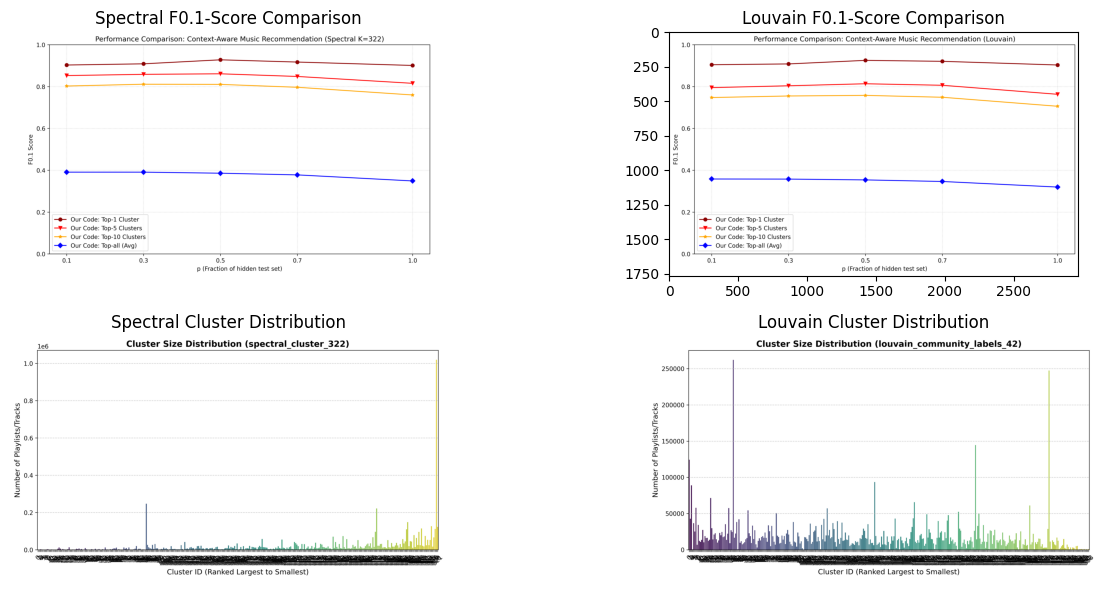

In [25]:
# Plotting the results side by side for comparison
spectral_322_path_fscore = os.path.join(spectral_report_out_322, "f01_comparison.png")
louvain_path_fscore = os.path.join(louvain_report_out, "f01_comparison.png")

spectral_322_path_dist = os.path.join(spectral_report_out_322, "cluster_distribution.png")
louvain_path_dist = os.path.join(louvain_report_out, "cluster_distribution.png")

# Plotting them side by side
fig, axes = plt.subplots(2, 2, figsize=(14, 6))
axes[0, 0].imshow(plt.imread(spectral_322_path_fscore))
axes[0, 0].set_title(f"{Spectral_322.algo_name} F0.1-Score Comparison")
axes[0, 0].axis('off')
axes[0, 1].imshow(plt.imread(louvain_path_fscore))
axes[0, 1].set_title(f"{Louvain.algo_name} F0.1-Score Comparison")
axes[1, 0].imshow(plt.imread(spectral_322_path_dist))
axes[1, 0].set_title(f"{Spectral_322.algo_name} Cluster Distribution")
axes[1, 0].axis('off')
axes[1, 1].imshow(plt.imread(louvain_path_dist))
axes[1, 1].set_title(f"{Louvain.algo_name} Cluster Distribution")
axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

#### Overall Predictive Trends
The evaluation results for our graph-based algorithms, Spectral Clustering and Louvain Community Detection, demonstrate a drastic improvement over the geometric approaches applied in Module 1. Both graph-based methods achieved exceptional predictive performance, with Top-1 Cluster $F_{0.1}$ scores peaking around 0.90 to 0.92 across all test fractions. 

It is important to acknowledge that a portion of this improvement stems from the significantly higher cluster granularity ($k=322$ vs $k=55$), which naturally creates tighter neighbourhoods and narrows the collaborative filtering search space. However, this high granularity is a direct benefit of our topological restructuring. K-means was proved by WCSS to provide diminishing returns at higher $k$ values, while the graph-based models successfully isolate 322 'optimal' communities.

Furthermore, if the algorithms were overfitting by creating artificially small clusters, their accuracy would plummet rapidly when forced to recommend higher fractions of the test set. Instead, both models exhibit strong resilience to increases in recommendation density ($p$), seeing only minor degradations as $p$ approaches 1.0. We attribute both these findings to the rich boundaries formed by the local contextual links in our graph preprocessing, forming semantic clusters where the recommendation system can continue to find relevant tracks even on higher quotas.


#### Spectral vs. Louvain
While both models peak at around 0.90 to 0.92 for Top-1 $F_{0.1}$ scores, Spectral Clustering demonstrates a structural advantage in broader recommendation brackets. It maintains noticeably higher Top-5 and Top-10 scores than Louvain, indicating more stable macro-partitions. This indicates that while Louvain's bottom up approach is able to find localized pockets of similarity, Spectral's approach of a Top-Down Global partitioning provides a more reliable recommendation across the entire dataset.

### Hypothesis For Limitations and Potential Improvements
While the shift to a network structure successfully mitigated the "gravity well" effect and improved our predictive baseline, the underlying methodology relies on assumptions that introduce new structural limitations. We hypothesize the following limitations and propose corresponding improvements:

#### K-NN Graph Limitations
**Limitation:** The creation of our K-NN graph involved setting the parameter $k=10$, signifying the amount of connections per cluster. However, this assumes that the musical landscape has a uniform density. In reality, mainstream contexts perhaps form large highly dense communities, while niche sub-genres form isolated more sparse pockets. A fixed $k$ artificially limits the natural connectivity of mainstream hubs while forcing weak connections upon other nodes, just to meet our defined quota.

**Improvement (Adaptive Neighbourhood Topologies):**  We propose replacing the rigid K-NN graph with a dynamic topology, specifically Mutual $k$-Nearest Neighbours (m-kNN) or an $\epsilon$-radius neighbourhood graph. By removing strict degree quotas, these methods accurately reflect the underlying data density by maintaining robust intra-cluster edges within mainstream hubs while isolating sparse outliers to prevent artificial bridging.

#### The Modularity Resolution Limit
**Limitation:** Louvain successfully constructs neighbourhoods based on local density, but its reliance on optimizing global Modularity leaves it highly susceptible to the "Resolution Limit." In a network of our scale (over 84,000 nodes and 640,000 edges) we hypothesize that with a resolution parameter of 1, Louvain is struggling to find small strongly connected communities, as the expected number of edges within it becomes so tiny that even a single edge connecting two small distinct communities can cause the algorithm to merge them.

**Improvement (Leiden Algorithm):** The Leiden Algorithm is an evolution of Louvain which adresses a number of key issues. The Leiden algorithm employs an intermediate refinement phase in which communities may be split to guarantee that all communities are well-connected. When paired with resolution-limit-free quality functions like the Constant Potts Model (CPM), this refinement ensures small, dense communities are accurately identified without being artificially merged (CITE).

#### Method Limits in Deterministic Partitioning
**Limitation:** In the above experiment we forced Spectral Clustering to partition the network into exactly 322 clusters to establish a controlled comparison with the Louvain baseline. However, as these two models are in many ways structural and algorithmic opposites, we hypothesise that we may be artificially locking Spectral to this cluster amount may be handicapping its linear algebraic logic. This argument could perhaps also be applied to the results from BIRCH in part 1, as the hierarchical clustering algorithm may benefit from a different granularity that the one selected for k-Means. 

**Improvement (Eigengap Heuristic):**
Rather than forcing Spectral Clustering to inherit k=322, we can let the graph structure determine its own natural partition size through the Eigengap heuristic. This method examines the eigenvalues of the normalized graph Laplacian and identifies the largest gap between consecutive eigenvalues, which indicates a stable transition in the network's connectivity structure. This should find Spectral Clustering a parameter based on the topology of the data itself, rather than the imposed one.


In [35]:
from graph.m_knn.m_knn_graph import M_KNN
MKNN = M_KNN(graph_builder.DiG)

# build mKNN
m_knn_graph = MKNN.build_graph(force_rebuild=True)

Building mutual k-NN using NetworkX Intersection...
Saving new NetworkX graph to .pkl file...
Graph saved successfully for future runs!


In [48]:
# Removing isolates
m_knn_graph_no_isolates = m_knn_graph.copy()
m_knn_graph_no_isolates.remove_nodes_from(list(nx.isolates(m_knn_graph_no_isolates)))

In [ ]:
# Running Spectral Clustering on the M-KNN graph, for k = 322
Spectral_MKNN_322 = SpectralGraphClustering(graph=m_knn_graph_no_isolates, n_clusters=322, graph_config_name=digraph_config_name)
Spectral_MKNN_322.cluster_col += "_mknn"

execution_pipeline(Spectral_MKNN_322, df, unique_texts, tfidf_matrix)

Checking for: 'spectral_cluster_322_mknn' in columns: ['user_id', 'artistname', 'trackname', 'playlistname', 'homogenized_playlist', 'is_contextual', 'filtered_playlist', 'expanded_features', 'k-means_cluster_55', 'birch_cluster_55']...

Executing Pipeline for: Spectral

Running spectral clustering on 50,399 graph nodes (k=322)...
Fitting spectral model on 50399 nodes...


/opt/homebrew/Caskroom/miniforge/base/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Added 'spectral_cluster_322_mknn' labels to the DataFrame.

============================== SPECTRAL COMMUNITY SAMPLES ==============================

[Community 115] (18 Unique Contexts)
  🎵 All I have                      
  🎵 Little Darling, Pal of Mine     
  🎵 Switchblade                     
  🎵 How Can I Keep from Singing -   
  🎵 Make Yourself                   

[Community 153] (29 Unique Contexts)
  🎵 Ensemble                        
  🎵 Try Again                       
  🎵 Square Heat Ambience Workout    
  🎵 J'te l'dis quand même           
  🎵 Comme des enfants - Radio Edit  

[Community 247] (44 Unique Contexts)
  🎵 Hate To See Your Heart Break    
  🎵 Baby Drives Me Crazy            
  🎵 Wheel Of Time                   
  🎵 Atoka, Atoka                    
  🎵 Truth And Beauty                

Generating report for Spectral...
[INFO] Saving updated labels to data/spotify_fully_processed.parquet...



[INFO] Evaluating Spectral results and saving report to 'clustering/reports/Spectral/k10_sim0.15_N84696_k322/evaluation_metrics_spectral_cluster_322_mknn.txt'...
Saving evaluation results to: clustering/reports/Spectral/k10_sim0.15_N84696_k322/

CALCULATING SILHOUETTE SCORE

CALCULATING SILHOUETTE SCORE FOR spectral_cluster_322_mknn
-> Final Silhouette Score (spectral_cluster_322_mknn): -0.1652

Processing Cluster 318.0...
Number of samples in Cluster 318.0: 762702
  -> Successfully split 7593 users into train/test sets.
  -> Sub-sampling to 200 users (out of 7593)...
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 296.0...
Number of samples in Cluster 296.0: 298051
  -> Successfully split 4031 users into train/test sets.
  -> Sub-sampling to 200 users (out of 4031)...
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 291.0...
Number of samples in Cluster 291.0: 292129
  -> Successfully split 2827 users into train/test sets.
  -> Sub-sampling to 200 users (out of 2827)...
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 320.0...
Number of samples in Cluster 320.0: 249377
  -> Successfully split 3496 users into train/test sets.
  -> Sub-sampling to 200 users (out of 3496)...
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 321.0...
Number of samples in Cluster 321.0: 221368
  -> Successfully split 3683 users into train/test sets.
  -> Sub-sampling to 200 users (out of 3683)...
  -> Generating recommendations & evaluating 200 sampled users...


...


  -> Successfully split 57 users into train/test sets.
  -> Evaluating all 57 users in this cluster...
  -> Generating recommendations & evaluating 57 sampled users...



Processing Cluster 184.0...
Number of samples in Cluster 184.0: 980
  -> Successfully split 30 users into train/test sets.
  -> Skipping cluster (Only 30 users. CF requires a larger crowd).

Processing Cluster 150.0...
Number of samples in Cluster 150.0: 976
  -> Successfully split 29 users into train/test sets.
  -> Skipping cluster (Only 29 users. CF requires a larger crowd).

Processing Cluster 160.0...
Number of samples in Cluster 160.0: 931


  -> Successfully split 44 users into train/test sets.
  -> Skipping cluster (Only 44 users. CF requires a larger crowd).

Processing Cluster 230.0...
Number of samples in Cluster 230.0: 930
  -> Successfully split 29 users into train/test sets.
  -> Skipping cluster (Only 29 users. CF requires a larger crowd).

Processing Cluster 123.0...
Number of samples in Cluster 123.0: 924
  -> Successfully split 46 users into train/test sets.
  -> Skipping cluster (Only 46 users. CF requires a larger crowd).

Processing Cluster 38.0...
Number of samples in Cluster 38.0: 924
  -> Successfully split 25 users into train/test sets.
  -> Skipping cluster (Only 25 users. CF requires a larger crowd).

Processing Cluster 224.0...
Number of samples in Cluster 224.0: 915
  -> Successfully split 30 users into train/test sets.
  -> Skipping cluster (Only 30 users. CF requires a larger crowd).

Processing Cluster 256.0...
Number of samples in Cluster 256.0: 893
  -> Successfully split 37 users into train/tes


Processing Cluster 194.0...
Number of samples in Cluster 194.0: 836
  -> Successfully split 41 users into train/test sets.
  -> Skipping cluster (Only 41 users. CF requires a larger crowd).

Processing Cluster 79.0...
Number of samples in Cluster 79.0: 824
  -> Successfully split 25 users into train/test sets.
  -> Skipping cluster (Only 25 users. CF requires a larger crowd).

Processing Cluster 63.0...
Number of samples in Cluster 63.0: 822
  -> Successfully split 22 users into train/test sets.
  -> Skipping cluster (Only 22 users. CF requires a larger crowd).

Processing Cluster 217.0...
Number of samples in Cluster 217.0: 818
  -> Successfully split 41 users into train/test sets.
  -> Skipping cluster (Only 41 users. CF requires a larger crowd).

Processing Cluster 137.0...
Number of samples in Cluster 137.0: 816
  -> Successfully split 29 users into train/test sets.
  -> Skipping cluster (Only 29 users. CF requires a larger crowd).

Processing Cluster 98.0...
Number of samples in 

  -> Successfully split 34 users into train/test sets.
  -> Skipping cluster (Only 34 users. CF requires a larger crowd).

Processing Cluster 162.0...
Number of samples in Cluster 162.0: 690
  -> Successfully split 33 users into train/test sets.
  -> Skipping cluster (Only 33 users. CF requires a larger crowd).

Processing Cluster 62.0...
Number of samples in Cluster 62.0: 688
  -> Successfully split 41 users into train/test sets.
  -> Skipping cluster (Only 41 users. CF requires a larger crowd).

Processing Cluster 179.0...
Number of samples in Cluster 179.0: 686
  -> Successfully split 27 users into train/test sets.
  -> Skipping cluster (Only 27 users. CF requires a larger crowd).

Processing Cluster 103.0...
Number of samples in Cluster 103.0: 683
  -> Successfully split 26 users into train/test sets.
  -> Skipping cluster (Only 26 users. CF requires a larger crowd).

Processing Cluster 111.0...
Number of samples in Cluster 111.0: 678
  -> Successfully split 36 users into train/tes

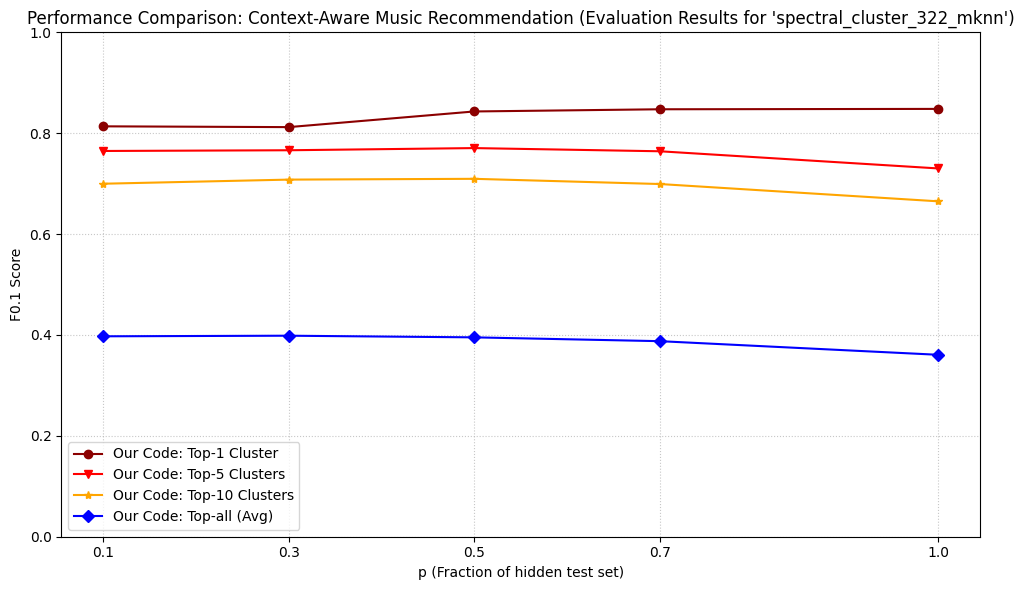


PLOTTING CLUSTER DISTRIBUTION
-> Distribution graph saved successfully to: clustering/reports/Spectral/k10_sim0.15_N84696_k322/cluster_distribution.png


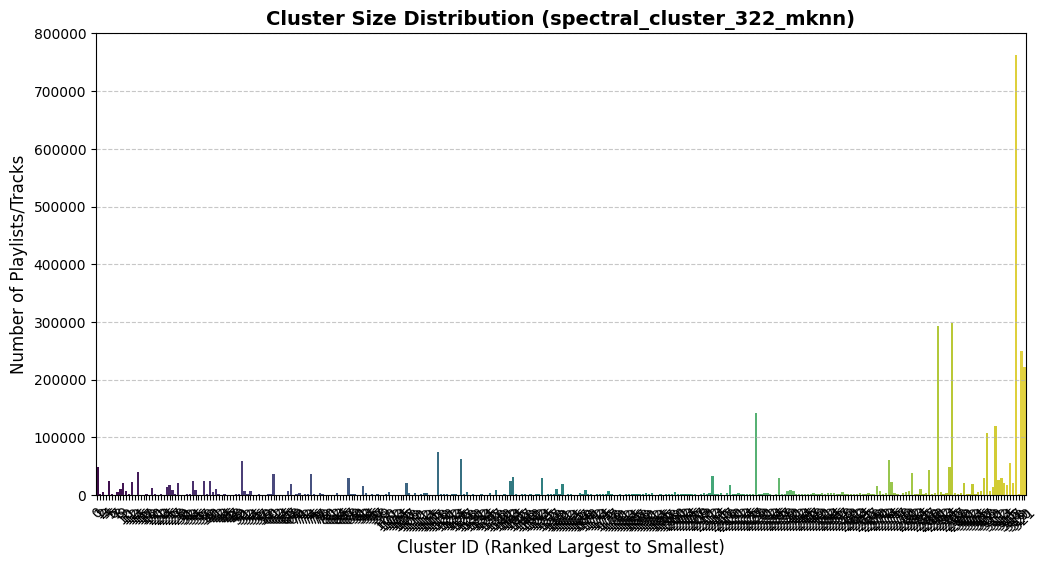


=== FINAL EVALUATION AVERAGES ===
Top-1 Average:   [np.float64(0.8136), np.float64(0.8121), np.float64(0.8431), np.float64(0.8475), np.float64(0.8482)]
Top-5 Average:   [np.float64(0.7648), np.float64(0.7662), np.float64(0.7705), np.float64(0.7642), np.float64(0.7302)]
Top-all Average: [np.float64(0.3974), np.float64(0.3985), np.float64(0.3953), np.float64(0.3877), np.float64(0.3607)]


In [53]:
# Evaluating Spectral Clustering on M-KNN graph
spectral_report_out_mknn_322 = evaluation_pipeline(Spectral_MKNN_322, df, unique_texts, tfidf_matrix)

## Further K Exploration **Draft**
We are comparing both models at a fixed parameter of $k = 322$, which provides a controlled baseline, Spectral Clustering deomnstrates a structural advantage, particularly in the broader recommendation brackets (maintaining higher Top-5 and Top-10 scores than Louvain). However, forcing Spectral Clustering to match the dynamic community count discovered by Louvain introduces a significant methological constraint. Louvain optimizes for network modularity and density, naturally settling on 322 communities as its ideal structural representation of the data. Spectral Clustering relies on identifying optimal mathematical cuts within the graph's eigenspace. 

By artificially restricting Spectral to 322 partitions, we are likely handicapping its underlying logic and forcing distinct semantic micro-communities to remain merged. This leads us to hypothesize that 322 is not the optimal parameter for Spectral in this high-dimensional space. To evaluate its true predicitve potential, we must decouple its parameterization from Louvain's density-based results, mathematically determine Spectral's own optimal number of clusters, and analyze its unconstrained performance. 

#### The Search of the Optimal K (Silhouettte and Eigengap Heuristics)
In tuning Spectral Clustering, we have had to pick $k$ as a hyperparameter, this $k$ has not been arbitrarily chosen. We started by calculating the *silhouette/eigengap* score for every $k$ up to 322, which was the optimal $k$ found by Louvain, seeing as the score kept increasing the interval was brought up to 1500, with sampling at every 50th $k$, the optimal $k$ was found at 700. To more accurately pin-point the exact $k$ we calculated silhouette scores of surrounding $k$s (675-725) finding $k = 720$ to be optimal. 

While we previously utilized a **Delta WCSS** threshold to determine $k=55$ for representative-based models, graph-based models requires a different form of validation in choosing the optimal hyperparameter $k$. 

- Eigengap Heuristic: We analyze the eigenvalues $\lambda$ of the graph Laplacian to find the largest difference between consecutive values, defined as $\delta_k = \lambda_{k+1} - \lambda_k$. A maximized gap indicates the number of stable, natural communities within the network density. 

- Average Silhouette Coefficient: Because spectral clustering projects the sparse TF-IDF data into a new, low-dimensional coordinate system, we use the silhouette coefficient to evaluate the quality of the resulting clusters within the **spectral embedding space**. 

- Davies-Bouldin Index (DBI): To provide a final check on the 'efficiency' of our high-granularity partition, we utilize the DBI. This metric identifies the average similarity between each cluster $i$ and its most similar neighbor $j$, where $s$ is the cluster diameter and $d_{ij}$ is the distance between centroids:

$$DBI = \frac{1}{k}\sum_{i=1}^kmax_{j \neq i}(\frac{s_i+s_j}{d_{ij}})$$

For any individual playlist $i$, the silhouette scores $s(i)$ is calculated by compaing its average distance to other points in the same cluster, i.e. its cohesion $a(i)$ against its average distance to points in the nearest neighboring cluster, i.e. its separation $b(i)$:

$$s(i) = \frac{b(i) - a(i)}{max(a(i), b(i))}$$

The means of these individual scores across the entire contextual dataset is used in guiding the selection of $k$ because of these following properties:
- A high average silhouette scores (approaching 1) indicated that the spectral transformation has successfully mapped the complex, arbitrary shapes of user-generated musical contexts into well-separated, compact clusters in the eigenvector space. 
- While the eigengap heuristic identifies candidate values for $k$ based on the graph's connectivity, the silhouette coefficient provides a geometric 'sanity check' to ensure these partitions are cohesive. 
- Since human musical curation is often nested or high-dimensional, scores near 0 alert us to overlapping contexts where $k$ may be too high, preventing the 'gravity well' effect previously observed in the K-Means implementation

By calculating this metric within the spectral embedding space, we can verify if the graph-based network representation offers a higher 'semantic purity' than our previous representative-based baseline.

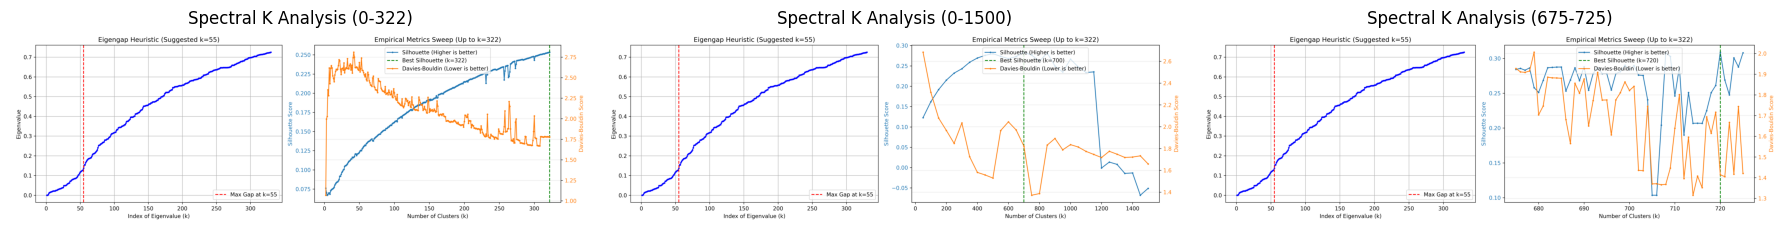

In [29]:
# Displaying of the silhouette scores, for different k values
path_img_1 = "scripts/data/spectral_k_analysis_spotify_0_322.png"
path_img_2 = "scripts/data/spectral_k_analysis_spotify_0_1500.png"
path_img_3 = "scripts/data/spectral_k_analysis_spotify_OPT720.png"

# 1x3 subplot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(plt.imread(path_img_1))
axes[0].set_title("Spectral K Analysis (0-322)")
axes[0].axis('off')
axes[1].imshow(plt.imread(path_img_2))
axes[1].set_title("Spectral K Analysis (0-1500)")
axes[1].axis('off')
axes[2].imshow(plt.imread(path_img_3))
axes[2].set_title("Spectral K Analysis (675-725)")
axes[2].axis('off')
plt.tight_layout()
plt.show()

The optimal $k$ was found to be 720, based on both the silhouette score maximized and a strong supporting DBI score, which was relatively low. They are not in agreement with eigengap which states that the optimal $k$ would be 55.

#### Executing Spectral Clustering - $k = 720$

In [30]:
# Initialize Spectral Clustering instance, and load the graph from the shared builder
from graph.knn.spectral_clustering import SpectralGraphClustering
Spectral_720 = SpectralGraphClustering(graph=graph_builder.G, n_clusters=720, graph_config_name=graph_config_name)

In [31]:
execution_pipeline(Spectral_720, df, unique_texts, tfidf_matrix)

Checking for: 'spectral_cluster_720' in columns: ['user_id', 'artistname', 'trackname', 'playlistname', 'homogenized_playlist', 'is_contextual', 'filtered_playlist', 'expanded_features', 'k-means_cluster_55', 'birch_cluster_55']...

[SKIP] Spectral already exists in column 'spectral_cluster_720'.


### Evaluation
#### Spectral Clustering Evaluation

In [32]:
spectral_report_path_720 = evaluation_pipeline(Spectral_720, df, unique_texts, tfidf_matrix)


[SKIP] Evaluation for Spectral already exists at 'clustering/reports/Spectral/k10_sim0.15_N84696_k720/evaluation_metrics_spectral_cluster_720.txt'.


#### Spectral vs. Louvain


[INFO] Displaying evaluation comparison graphs for Spectral and Louvain...


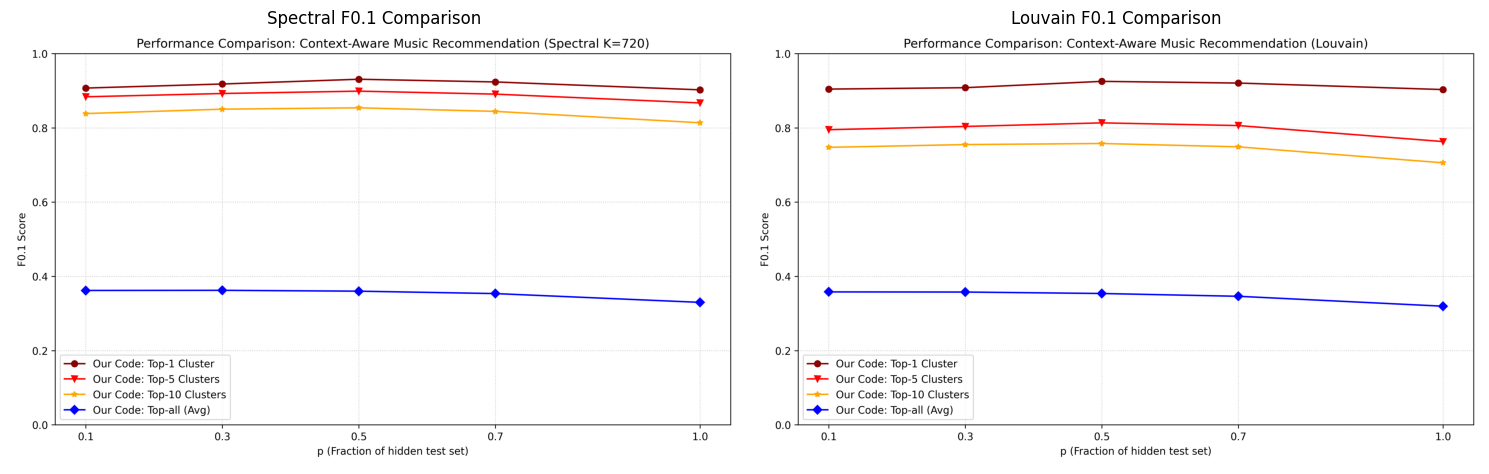

In [33]:
# Printing the two graphs side by side for comparison
if os.path.exists(spectral_report_path_720) and os.path.exists(louvain_report_out):
    print("\n[INFO] Displaying evaluation comparison graphs for Spectral and Louvain...")
    
    spectral_f01 = os.path.join(spectral_report_path_720, "f01_comparison.png")
    louvain_f01 = os.path.join(louvain_report_out, "f01_comparison.png")
    
    if os.path.exists(spectral_f01) and os.path.exists(louvain_f01):
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        axes[0].imshow(plt.imread(spectral_f01))
        axes[0].set_title(f"{Spectral_720.algo_name} F0.1 Comparison")
        axes[0].axis('off')
        
        axes[1].imshow(plt.imread(louvain_f01))
        axes[1].set_title(f"{Louvain.algo_name} F0.1 Comparison")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        print("[WARNING] One or both F0.1 comparison graphs are missing. Cannot display side by side.")